# Analysis of Long-Term Care Resources and Demand in Taiwan

This project analyzes the relationship between elderly population, long-term care service demand, and long-term care resource allocation across counties in Taiwan.

By integrating multiple datasets, the analysis explores whether long-term care resources are aligned with the needs of an aging population.

# Motivation

Taiwan is experiencing rapid population aging, which significantly increases the demand for long-term care services.

Understanding how long-term care resources are distributed relative to population aging is important for evaluating whether current resource allocation meets regional care needs.

This project aims to examine the relationship between:
- Elderly population
- Long-term care service usage
- Long-term care resource distribution

across different counties in Taiwan.

# Research Questions

This project aims to answer the following questions:

1. Do counties with larger elderly populations have higher long-term care service demand?
2. Are long-term care resources distributed according to service demand?
3. Which counties experience the highest pressure on long-term care resources?

# Data Sources

Three datasets are used in this project:

1. **Elderly Population Dataset**
   - Contains the population aged 65 and above by county.

2. **Long-Term Care Service Usage Dataset**
   - Records the number of people using long-term care services in each county.

3. **Long-Term Care Resource Dataset**
   - Provides the number of long-term care resources including service centers and care stations.

These datasets are merged using the county name as the key variable.

### Load and Clean Elderly Population Dataset

The first dataset contains the population age structure by county in Taiwan.  
This dataset is used to obtain the number of elderly people (age 65 and above), which represents the potential demand for long-term care services.

The Excel file includes several header rows and a summary row.  
To prepare the dataset for analysis, the following preprocessing steps are performed:

- Skip the first three rows that contain metadata rather than actual data.
- Rename the first column to **county** to standardize the dataset.
- Remove the row labeled **總計**, which represents the national total rather than an individual county.
- Reset the index to ensure a clean DataFrame.

After cleaning, the dataset contains county-level population information that can be used for further analysis.

In [6]:
import pandas as pd
elderly = pd.read_excel(
    "縣市人口年齡結構指標-115年2月.xls",
    skiprows=3
)

elderly = elderly.rename(columns={"Unnamed: 0": "county"})
elderly = elderly[elderly["county"] != "總計"]
elderly = elderly.reset_index(drop=True)

elderly.head()

,county,計,男,女,計.1,男.1,女.1,％,計.2,男.2,...,女.5,％.4,計.6,男.6,女.6,％.5,計.7,男.7,女.7,％.6
0,總 計,23280273.0,11450829.0,11829444.0,674154.0,348603.0,325551.0,2.895817,1014436.0,524891.0,...,574554.0,5.131220,19642978.0,9565036.0,10077942.0,84.376064,4707676.0,2119084.0,2588592.0,20.221739
1,新北市,4043220.0,1960515.0,2082705.0,104939.0,53998.0,50941.0,2.595431,159890.0,82296.0,...,96736.0,4.972497,3445959.0,1651645.0,1794314.0,85.228086,813604.0,357363.0,456241.0,20.122675
2,臺北市,2434479.0,1146180.0,1288299.0,70639.0,36190.0,34449.0,2.901606,106241.0,54649.0,...,61721.0,5.248187,2049367.0,947491.0,1101876.0,84.180927,592649.0,257830.0,334819.0,24.343977
3,桃園市,2355512.0,1158038.0,1197474.0,81229.0,41813.0,39416.0,3.448465,121348.0,62618.0,...,63658.0,5.621495,1941511.0,943297.0,998214.0,82.424161,397738.0,178600.0,219138.0,16.885416
4,臺中市,2868409.0,1397771.0,1470638.0,90964.0,47202.0,43762.0,3.171235,137551.0,71292.0,...,77113.0,5.576088,2376311.0,1142767.0,1233544.0,82.844218,503511.0,225965.0,277546.0,17.553668


### Extract Elderly Population Data

The original dataset contains population counts for multiple age groups.  
For this analysis, only the population aged **65 and above** is needed because this group represents the primary users of long-term care services.

The following steps are performed:

- Select only the columns **county** and the column representing **population aged 65+**.
- Rename the age column to **elderly_population** for clarity.
- Remove extra whitespace in county names to ensure consistency across datasets.
- Remove the summary row labeled **總計**, which represents the national total rather than a county.
- Reset the index to maintain a clean DataFrame.

The resulting dataset contains two variables:
- **county** – the county name
- **elderly_population** – the number of residents aged 65 and above

In [8]:
elderly_clean = elderly[["county", "計.7"]]

elderly_clean = elderly_clean.rename(
    columns={"計.7": "elderly_population"}
)

elderly_clean["county"] = elderly_clean["county"].str.strip()
elderly_clean = elderly_clean[elderly_clean["county"] != "總    計"]
elderly_clean = elderly_clean.reset_index(drop=True)

elderly_clean.head()

,county,elderly_population
0,新北市,813604.0
1,臺北市,592649.0
2,桃園市,397738.0
3,臺中市,503511.0
4,臺南市,382363.0


In [9]:
!pip install tabula-py

### Load Long-Term Care Service Usage Dataset

The second dataset records the number of people using long-term care services in each county.

Since the dataset is provided in **PDF format**, the `tabula` library is used to extract the tables directly from the PDF file.

The `read_pdf()` function reads all pages of the document and stores the detected tables in a list.  
The `multiple_tables=True` option allows the program to capture multiple tables if they exist within the PDF.

Finally, `len(tables)` is used to check how many tables were successfully extracted from the PDF file.

In [11]:
import tabula

tables = tabula.read_pdf(
    "長照服務使用量.pdf",
    pages="all",
    multiple_tables=True
)

len(tables)

Failed to import jpype dependencies. Fallback to subprocess.
No module named 'jpype'


3

### Inspect Extracted Table

After extracting tables from the PDF file, the first table in the list is selected for further analysis.

This table contains the number of long-term care service users for each county.

The `head()` function is used to display the first few rows of the table, allowing us to verify that the data was extracted correctly and to understand the structure of the dataset before cleaning.

In [13]:
service_users = tables[0]

service_users.head()

,服務項目\r居住區,長照給付支付\r服務總人數,A,B,BA,BB,BC,BD,C,D,EF,G
0,NaN,NaN,照顧管理服務\r及政策鼓勵,照顧服務,居家服務,日間照顧,家庭托顧,社區式交通接\r送、晚餐、沐\r浴服務,專業服務,交通接送,輔具及居家無\r障礙環境改善\r服務,喘息服務
1,全國,"558,071","543,377","395,075","363,943","42,661","1,575","41,090","85,020","256,990","138,600","191,206"
2,新北市,"77,977","75,328","50,090","47,064","4,882",37,"3,687","15,791","51,514","18,077","34,656"
3,臺北市,"51,057","49,340","26,886","24,756","3,281",31,"1,959","8,865","40,928","16,423","10,824"
4,桃園市,"39,906","39,192","28,095","25,751","3,255",28,"2,759","6,446","17,017","10,001","17,047"


### Clean Long-Term Care Service Usage Data

The extracted table from the PDF contains additional rows and formatting that need to be cleaned before analysis.

The following preprocessing steps are performed:

- Select only the first two columns, which represent the **county name** and the **number of long-term care service users**.
- Rename the columns to **county** and **service_users** for clarity.
- Remove rows with missing values that may have been introduced during the PDF extraction process.
- Standardize county names by removing extra whitespace.
- Remove the row labeled **全國**, which represents the national total rather than a specific county.
- Convert the service user values from text format (with commas) to numeric integers.
- Reset the index to produce a clean dataset.

The resulting dataset provides the number of long-term care service users for each county.

In [15]:
service_users = service_users.iloc[:, [0,1]]

service_users.columns = ["county", "service_users"]

service_users = service_users.dropna()

service_users["county"] = service_users["county"].str.strip()
service_users = service_users[service_users["county"] != "全國"]

service_users["service_users"] = (
    service_users["service_users"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(int)
)

service_users = service_users.reset_index(drop=True)

service_users.head()

,county,service_users
0,新北市,77977
1,臺北市,51057
2,桃園市,39906
3,臺中市,63006
4,臺南市,52580


### Load Long-Term Care Resource Dataset

The third dataset contains information about the distribution of long-term care resources across counties in Taiwan.

Similar to the service usage dataset, this data is provided in **PDF format**.  
Therefore, the `tabula` library is used to extract tables directly from the PDF file.

The `read_pdf()` function reads all pages of the document and stores the detected tables in a list.  
The `multiple_tables=True` option allows the program to capture multiple tables if they appear within the PDF.

Finally, `len(tables)` is used to verify how many tables were successfully extracted from the PDF.

In [17]:
tables = tabula.read_pdf(
    "長照資源.pdf",
    pages="all",
    multiple_tables=True
)

len(tables)

1

### Inspect Extracted Long-Term Care Resource Table

After extracting tables from the long-term care resource PDF, the first table in the list is selected for analysis.

This table contains information about the distribution of long-term care resources across counties, including different types of service units.

The `head()` function is used to display the first few rows of the table in order to confirm that the data has been extracted correctly and to understand the structure of the dataset before performing data cleaning.

In [19]:
ltc_resources = tables[0]

ltc_resources.head()

,服務資源別\r縣市別,社區整體照顧服務體系,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,A\r(社區整合型服務中心),B\r(長照特約服務單位),C\r(巷弄長照站),NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,目標值,實際值,達成率,目標值,實際值,達成率,目標值,實際值,達成率
2,新北市,43,111,258%,82,"1,297",1582%,334,479,143%
3,臺北市,34,70,206%,73,635,870%,177,293,166%
4,桃園市,26,78,300%,59,679,1151%,169,418,247%


### Clean and Prepare Long-Term Care Resource Data

The extracted table from the PDF contains multiple columns and formatting elements that need to be processed before analysis.

The following steps are applied to prepare the dataset:

- Select only the relevant columns representing **county name** and the three types of long-term care resources.
- Rename the columns for clarity:
  - **A_centers** – Community integrated service centers  
  - **B_units** – Long-term care service units  
  - **C_stations** – Community care stations
- Remove the first two rows, which contain table headers rather than actual data.
- Standardize county names by removing extra whitespace.
- Convert numeric values stored as text into integers and remove comma separators.
- Reset the DataFrame index to ensure a clean structure.

After cleaning, a new variable **total_resources** is created by summing the three resource categories.  
This variable represents the **total number of long-term care resources available in each county** and will be used in the later analysis.

In [21]:
ltc_resources = tables[0].iloc[:, [0, 2, 5, 8]]

ltc_resources.columns = [
    "county",
    "A_centers",
    "B_units",
    "C_stations"
]

ltc_resources = ltc_resources.drop([0, 1])

ltc_resources["county"] = ltc_resources["county"].str.strip()

for col in ["A_centers", "B_units", "C_stations"]:
    ltc_resources[col] = pd.to_numeric(
        ltc_resources[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce"
    ).fillna(0).astype(int)

ltc_resources = ltc_resources.reset_index(drop=True)

ltc_resources["total_resources"] = (
    ltc_resources["A_centers"] +
    ltc_resources["B_units"] +
    ltc_resources["C_stations"]
)

ltc_resources = ltc_resources[["county", "total_resources"]]

ltc_resources.head()

,county,total_resources
0,新北市,1887
1,臺北市,998
2,桃園市,1175
3,臺中市,2019
4,臺南市,1501


## Data Integration

After cleaning the three datasets, they are combined into a single DataFrame to enable joint analysis.

The datasets merged in this step include:

- **Elderly population dataset** – number of residents aged 65 and above in each county
- **Long-term care service usage dataset** – number of people using long-term care services
- **Long-term care resource dataset** – total number of long-term care resources

The datasets are merged using **county** as the key variable.

This integration allows us to analyze the relationship between:
- population aging,
- long-term care demand, and
- long-term care resource allocation.

In [23]:
df = pd.merge(
    elderly_clean,
    service_users,
    on="county"
)

df = pd.merge(
    df,
    ltc_resources,
    on="county"
)

df.head()

,county,elderly_population,service_users,total_resources
0,新北市,813604.0,77977,1887
1,臺北市,592649.0,51057,998
2,桃園市,397738.0,39906,1175
3,臺中市,503511.0,63006,2019
4,臺南市,382363.0,52580,1501


# Summary Statistics

Summary statistics are used to understand the basic characteristics of the dataset.

The table below presents descriptive statistics for key variables including elderly population, long-term care service usage, and long-term care resources.

These statistics provide an overview of the scale and variation of long-term care demand and resources across counties.

In [25]:
df.describe()

,elderly_population,service_users,total_resources
count,22.000000,22.000000,22.000000
mean,213985.272727,25366.863636,725.545455
std,226257.171824,23750.795975,647.131894
min,2356.000000,46.000000,15.000000
25%,69364.250000,8269.750000,242.000000
50%,107497.500000,15493.000000,507.500000
75%,348848.000000,37726.750000,957.750000
max,813604.000000,77977.000000,2178.000000


## Correlation Analysis

To further examine relationships between variables, a correlation matrix is calculated.

This analysis helps identify how strongly elderly population, long-term care demand, and resource availability are related.

A strong positive correlation between elderly population and service usage would indicate that aging demographics play an important role in driving long-term care demand.

In [27]:
df[[
    "elderly_population",
    "service_users",
    "total_resources"
]].corr()

,elderly_population,service_users,total_resources
elderly_population,1.000000,0.968384,0.902869
service_users,0.968384,1.000000,0.975850
total_resources,0.902869,0.975850,1.000000


## Visualization: Elderly Population vs Long-Term Care Service Usage

To explore the relationship between population aging and long-term care demand, a scatter plot is created.

The horizontal axis represents the **elderly population (age 65+)**, which indicates the potential demand for long-term care services.

The vertical axis represents the **number of long-term care service users**, which reflects the actual usage of long-term care services.

Each point in the plot corresponds to a county, and county names are labeled directly on the graph to make the comparison easier.

This visualization helps reveal whether counties with larger elderly populations tend to have higher demand for long-term care services.

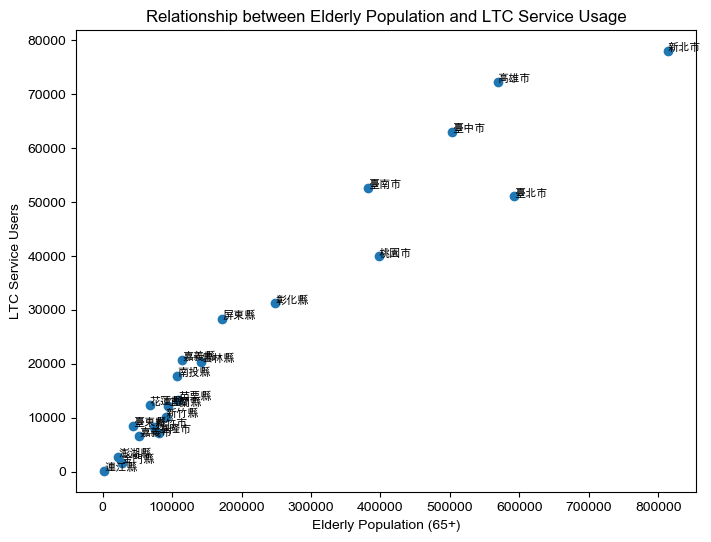

In [29]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8,6))

plt.scatter(df["elderly_population"], df["service_users"])

for i, row in df.iterrows():
    plt.text(
        row["elderly_population"],
        row["service_users"],
        row["county"],
        fontsize=8
    )

plt.xlabel("Elderly Population (65+)")
plt.ylabel("LTC Service Users")
plt.title("Relationship between Elderly Population and LTC Service Usage")

plt.show()

### Indicator: Elderly Population per Long-Term Care Resource

To better understand the balance between population aging and long-term care resource allocation, a new indicator is created.

The indicator **elderly_per_resource** represents the number of elderly residents served by each long-term care resource.

The formula used is:

elderly_per_resource = elderly_population / total_resources

A higher value indicates that each resource needs to serve more elderly people, which may suggest higher pressure on the long-term care system in that county.

This indicator helps identify regions where long-term care resources may be relatively insufficient compared to the size of the elderly population.

In [31]:
df["elderly_per_resource"] = (
    df["elderly_population"] / df["total_resources"]
)

df.head()

,county,elderly_population,service_users,total_resources,elderly_per_resource
0,新北市,813604.0,77977,1887,431.162692
1,臺北市,592649.0,51057,998,593.836673
2,桃園市,397738.0,39906,1175,338.500426
3,臺中市,503511.0,63006,2019,249.386330
4,臺南市,382363.0,52580,1501,254.738841


### Identify Counties with the Highest Resource Pressure

To understand which counties may experience the greatest pressure on long-term care resources, the dataset is sorted by the indicator **elderly_per_resource** in descending order.

This step highlights the counties where each long-term care resource must serve the largest number of elderly residents.

By examining the top counties in this ranking, we can identify areas where long-term care resources may be relatively insufficient compared to the size of the aging population.

In [33]:
df.sort_values(
    "elderly_per_resource",
    ascending=False
).head(10)

,county,elderly_population,service_users,total_resources,elderly_per_resource
1,臺北市,592649.0,51057,998,593.836673
20,金門縣,27573.0,1621,63,437.666667
0,新北市,813604.0,77977,1887,431.162692
18,新竹市,74264.0,8210,189,392.931217
17,基隆市,80745.0,7204,215,375.558140
2,桃園市,397738.0,39906,1175,338.500426
9,彰化縣,248303.0,31189,788,315.105330
19,嘉義市,52425.0,6607,171,306.578947
7,新竹縣,90815.0,10214,323,281.160991
8,苗栗縣,108229.0,13285,405,267.232099


## Visualization: Counties with the Highest Long-Term Care Resource Pressure

To better illustrate regional differences in long-term care resource pressure, a bar chart is created using the **top 10 counties** with the highest values of the indicator *elderly_per_resource*.

This visualization shows how many elderly residents are supported by each long-term care resource in different counties.

A higher value indicates that each resource must serve more elderly people, suggesting that the county may experience greater pressure on its long-term care system.

The bar chart allows us to easily compare which counties may face the greatest imbalance between elderly population and available long-term care resources.

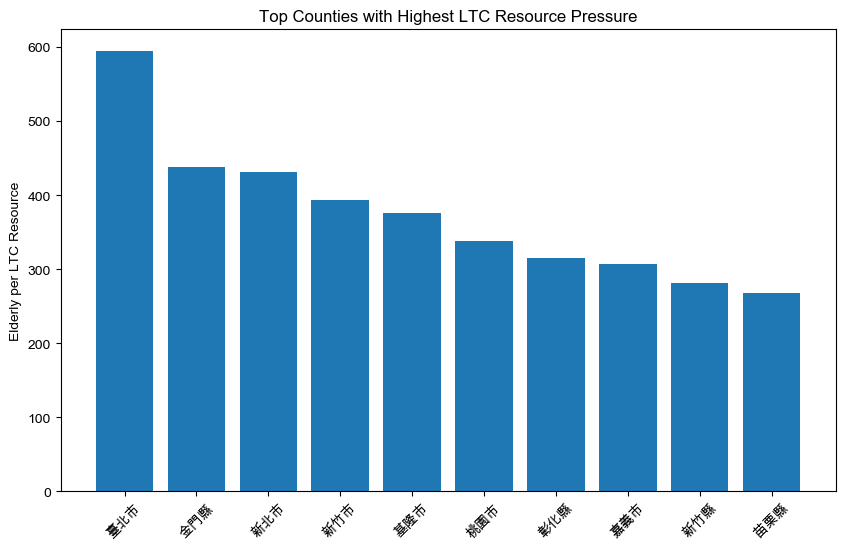

In [35]:
top10 = df.sort_values(
    "elderly_per_resource",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10["county"],
    top10["elderly_per_resource"]
)

plt.xticks(rotation=45)

plt.ylabel("Elderly per LTC Resource")
plt.title("Top Counties with Highest LTC Resource Pressure")

plt.show()

### Indicator: Long-Term Care Service Coverage Rate

In addition to resource availability, it is also important to understand how widely long-term care services are actually used among the elderly population.

To measure this, a new indicator called **service_coverage_rate** is calculated.

The formula used is:

service_coverage_rate = service_users / elderly_population

This indicator represents the proportion of elderly residents who are using long-term care services in each county.

A higher value suggests that long-term care services are more widely utilized among the elderly population, while a lower value may indicate potential barriers to access or lower service demand.

In [37]:
df["service_coverage_rate"] = (
    df["service_users"] / df["elderly_population"]
)

df.head()

,county,elderly_population,service_users,total_resources,elderly_per_resource,service_coverage_rate
0,新北市,813604.0,77977,1887,431.162692,0.095841
1,臺北市,592649.0,51057,998,593.836673,0.086150
2,桃園市,397738.0,39906,1175,338.500426,0.100332
3,臺中市,503511.0,63006,2019,249.386330,0.125133
4,臺南市,382363.0,52580,1501,254.738841,0.137513


### Identify Counties with the Highest Long-Term Care Service Coverage

To further analyze how widely long-term care services are used, the dataset is sorted by the indicator **service_coverage_rate** in descending order.

This step identifies the counties where the largest proportion of elderly residents are currently using long-term care services.

Examining these counties can help reveal regional differences in service accessibility, demand, or policy implementation related to long-term care.

In [39]:
df.sort_values(
    "service_coverage_rate",
    ascending=False
).head(10)

,county,elderly_population,service_users,total_resources,elderly_per_resource,service_coverage_rate
14,臺東縣,43895.0,8449,395,111.126582,0.192482
15,花蓮縣,67731.0,12378,388,174.564433,0.182752
12,嘉義縣,114792.0,20736,654,175.522936,0.180640
10,南投縣,106766.0,17701,501,213.105788,0.165792
13,屏東縣,171866.0,28336,837,205.335723,0.164873
11,雲林縣,142326.0,20330,630,225.914286,0.142841
4,臺南市,382363.0,52580,1501,254.738841,0.137513
6,宜蘭縣,93993.0,12157,514,182.865759,0.129339
5,高雄市,569133.0,72317,2178,261.309917,0.127065
19,嘉義市,52425.0,6607,171,306.578947,0.126028


## Visualization: Counties with the Highest Long-Term Care Service Coverage

To better understand regional differences in the utilization of long-term care services, a bar chart is created showing the **top 10 counties with the highest service coverage rates**.

The service coverage rate represents the proportion of elderly residents who are using long-term care services in each county.

By visualizing these counties, we can compare how widely long-term care services are utilized across different regions.  
Counties with higher coverage rates may indicate better accessibility to long-term care services or higher demand among the elderly population.

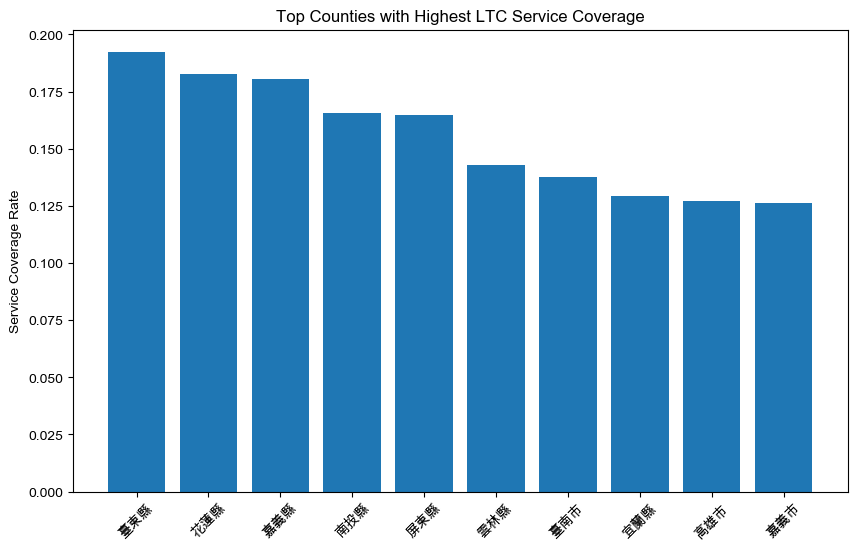

In [41]:
top10 = df.sort_values(
    "service_coverage_rate",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10["county"],
    top10["service_coverage_rate"]
)

plt.xticks(rotation=45)

plt.ylabel("Service Coverage Rate")
plt.title("Top Counties with Highest LTC Service Coverage")

plt.show()

## Statistical Modeling: Linear Regression

To further analyze the relationship between population aging and long-term care demand, a **linear regression model** is applied.

In this model:

- **Independent variable (X):** elderly_population  
- **Dependent variable (y):** service_users

The model examines whether the size of the elderly population can help explain the number of people using long-term care services in each county.

Linear regression is used to estimate the relationship between these two variables and determine how changes in elderly population size are associated with changes in long-term care service demand.

The model outputs two key parameters:

- **Coefficient (slope):** indicates how much long-term care service usage increases when the elderly population increases.
- **Intercept:** represents the baseline level of service usage when the elderly population is zero.

This statistical modeling step provides a quantitative way to evaluate the relationship between aging demographics and long-term care demand.

In [43]:
!pip install scikit-learn

from sklearn.linear_model import LinearRegression
import numpy as np

X = df[["elderly_population"]]
y = df["service_users"]

model = LinearRegression()

model.fit(X, y)

model.coef_, model.intercept_

(array([0.10165373]), 3614.463512569837)

### Predict Long-Term Care Service Demand

After fitting the linear regression model, the model is used to generate predicted values for long-term care service usage.

The `predict()` function estimates the number of long-term care service users based on the elderly population in each county.

The predicted values are stored in a new column called **predicted_users**.

This allows us to compare the **actual number of service users** with the **model's predicted values**, which helps evaluate how well elderly population size explains long-term care demand across counties.

In [45]:
df["predicted_users"] = model.predict(X)

df.head()

,county,elderly_population,service_users,total_resources,elderly_per_resource,service_coverage_rate,predicted_users
0,新北市,813604.0,77977,1887,431.162692,0.095841,86320.341000
1,臺北市,592649.0,51057,998,593.836673,0.086150,63859.442135
2,桃園市,397738.0,39906,1175,338.500426,0.100332,44046.012891
3,臺中市,503511.0,63006,2019,249.386330,0.125133,54798.232373
4,臺南市,382363.0,52580,1501,254.738841,0.137513,42483.086865


## Visualization of Regression Results

To illustrate the relationship between elderly population and long-term care service demand, a regression plot is created.

The scatter points represent the **actual observed data**, showing the relationship between the number of elderly residents and the number of long-term care service users in each county.

The red line represents the **predicted values generated by the linear regression model**. This regression line shows the overall trend estimated by the model.

By comparing the observed data points with the regression line, we can visually evaluate how well elderly population size explains long-term care service usage across counties.

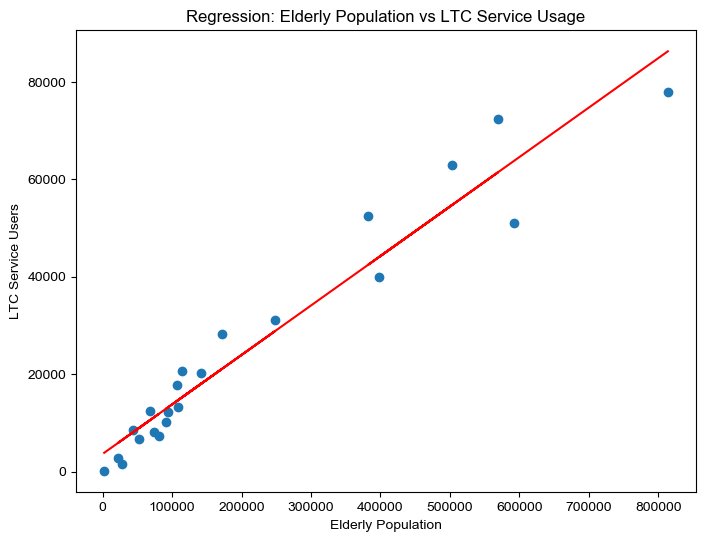

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(df["elderly_population"], df["service_users"])

plt.plot(
    df["elderly_population"],
    df["predicted_users"],
    color="red"
)

plt.xlabel("Elderly Population")
plt.ylabel("LTC Service Users")
plt.title("Regression: Elderly Population vs LTC Service Usage")

plt.show()

## Correlation Analysis

To better understand the relationships between key variables, a correlation matrix is calculated and visualized using a heatmap.

The heatmap shows the strength and direction of relationships between:

- elderly population
- long-term care service usage
- long-term care resources
- resource pressure indicators
- service coverage rates

Correlation values range from -1 to 1, where values closer to 1 indicate strong positive relationships.

This visualization helps identify which factors are most strongly associated with long-term care demand.

In [49]:
import seaborn as sns
corr = df[[
    "elderly_population",
    "service_users",
    "total_resources",
    "elderly_per_resource",
    "service_coverage_rate"
]].corr()

corr

,elderly_population,service_users,total_resources,elderly_per_resource,service_coverage_rate
elderly_population,1.000000,0.968384,0.902869,0.488062,-0.121714
service_users,0.968384,1.000000,0.975850,0.320753,0.022782
total_resources,0.902869,0.975850,1.000000,0.161234,0.101006
elderly_per_resource,0.488062,0.320753,0.161234,1.000000,-0.525601
service_coverage_rate,-0.121714,0.022782,0.101006,-0.525601,1.000000


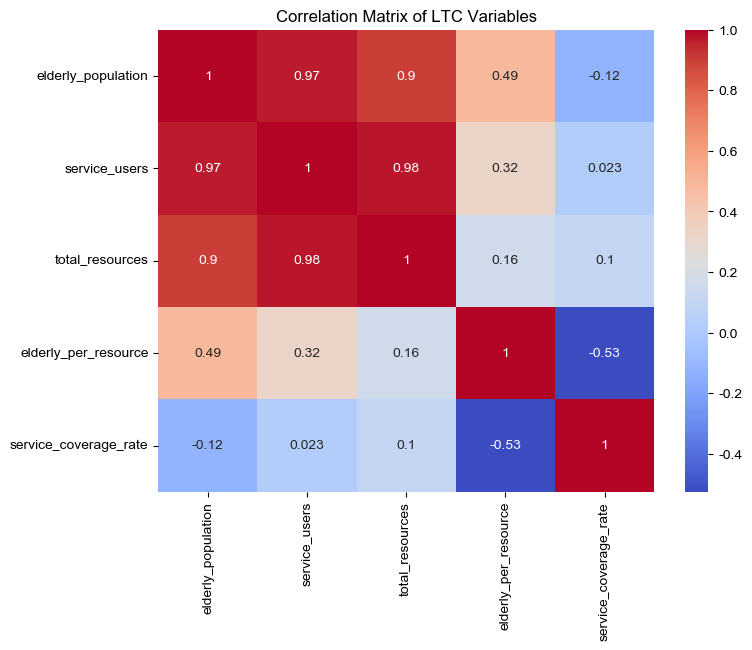

In [50]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of LTC Variables")

plt.show()

# Findings

Several key findings emerge from this analysis.

First, counties with larger elderly populations tend to have higher long-term care service usage, indicating that population aging is a major driver of long-term care demand.

Second, there are noticeable differences in long-term care resource allocation across counties. Some regions experience higher resource pressure, where each long-term care resource must serve a larger number of elderly residents.

Finally, service coverage rates vary between counties, suggesting differences in accessibility or demand for long-term care services.

# Conclusion

This project examined the relationship between elderly population, long-term care demand, and resource allocation across counties in Taiwan.

The analysis shows that population aging strongly influences long-term care service demand. Counties with larger elderly populations generally experience higher service usage.

However, differences in resource availability suggest that long-term care resources may not always be evenly distributed relative to demand.

These findings highlight the importance of aligning long-term care resource planning with demographic changes to better support an aging society.

# Environment Information

Python version used for this project:

Python 3.12.7

In [54]:
import sys
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:28:27) [Clang 14.0.6 ]


# Requirements

The following Python packages were used in this project:
pandas  
numpy  
matplotlib  
seaborn  
scikit-learn  
tabula-py

In [56]:
!pip freeze

aext-assistant @ file:///private/var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_e8wd_39o7u/croot/aext-assistant_1734643594996/work
aext-assistant-server @ file:///private/var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_11co_dx32p/croot/aext-assistant-server_1734640107264/work
aext-core @ file:///private/var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_abh4583law/croot/aext-core_1734637785810/work
aext-core-server @ file:///private/var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_b5dgq8d0kd/croot/aext-core-server_1734635062953/work
aext-panels @ file:///private/var/folders/c_/qfmhj66j0tn016nkx_th4hxm0000gp/T/abs_da4npqhdda/croot/aext-panels_1734642945557/work
aext-panels-server @ file:///private/var/folders/c_/qfmhj66j0tn016nkx_th4hxm0000gp/T/abs_c7k0q592nv/croot/aext-panels-server_1734639713336/work
aext-project-filebrowser-server @ file:///private/var/folders/sy/f16zz6x50xz3113nwtb9bvq00000gp/T/abs_71g16r1gvy/croot/aext-project-filebrowser-server_1734687927420/work/back